In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

In [2]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


In [4]:
#print(X_train[0])

Preprocessing:
Normalization of pixel values to 0–1,
Reshape images to (28, 28, 1) for the CNN,
Separate training, validation and test sets 
and
Data augmentation for the training images

In [5]:
print("Data type:", X_train.dtype)
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [6]:
# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [7]:
#reshaping
print(X_train.shape)

#Reshaping for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
print("Training images shape:", X_train.shape)
print("Testing images shape:", X_test.shape)

(60000, 28, 28)
Training images shape: (60000, 28, 28, 1)
Testing images shape: (10000, 28, 28, 1)


In [8]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (48000, 28, 28, 1)
Validation set: (12000, 28, 28, 1)
Test set: (10000, 28, 28, 1)


In [9]:
#aug
train_datagen = ImageDataGenerator( rotation_range=10, width_shift_range=0.1, height_shift_range=0.1, zoom_range=0.1)

CNN Model

In [10]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1785177858.460338      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785177858.463744      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_mnist_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

model.save("mnist_cnn_model.keras")
print("Model Saved!")

Epoch 1/20
  17/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.1518 - loss: 2.2688

I0000 00:00:1785177864.780552      69 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7361 - loss: 0.8066
Epoch 1: val_accuracy improved from None to 0.98050, saving model to best_mnist_model.keras

Epoch 1: finished saving model to best_mnist_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8541 - loss: 0.4619 - val_accuracy: 0.9805 - val_loss: 0.0669
Epoch 2/20
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9403 - loss: 0.2028
Epoch 2: val_accuracy improved from 0.98050 to 0.98283, saving model to best_mnist_model.keras

Epoch 2: finished saving model to best_mnist_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9436 - loss: 0.1886 - val_accuracy: 0.9828 - val_loss: 0.0512
Epoch 3/20
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9541 - loss: 0.1499
Epoch 3: val_accuracy improved from 0.98283 to 0.98833, saving model to best_mnist_model.keras

Epoch 3: finished saving model to best_mnist_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step -

In [13]:
import os
os.makedirs("results", exist_ok=True)

with open("results/model_summary.txt", "w") as f:
    model.summary(print_fn=lambda x: f.write(x + "\n"))

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9948 - loss: 0.0176
Test Loss: 0.017610082402825356
Test Accuracy: 0.9947999715805054


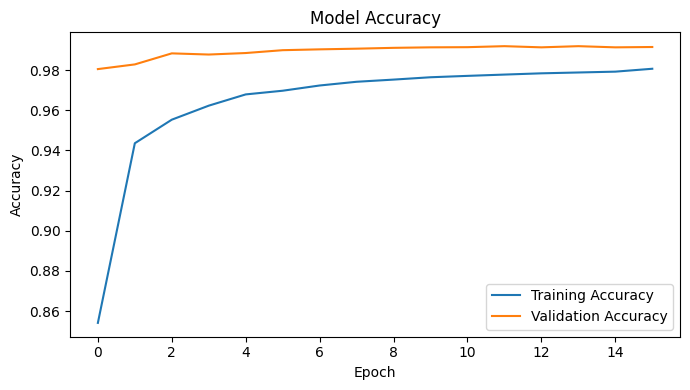

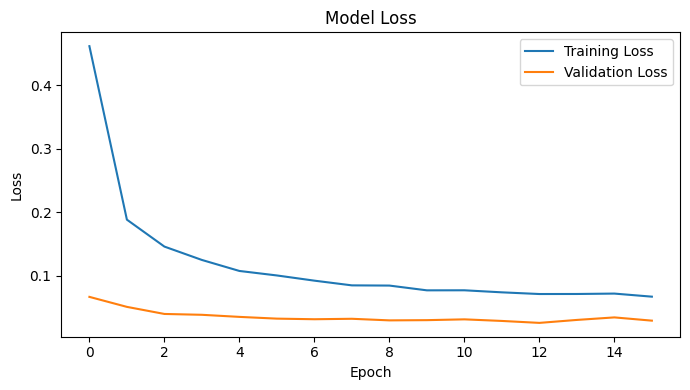

In [14]:

plt.figure(figsize=(7,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("results/accuracy.png")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("results/loss.png")
plt.show()

In [15]:
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

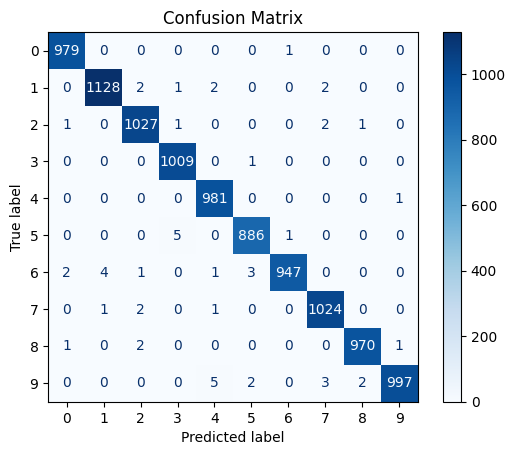

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      0.99      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      1.00      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.savefig("results/confusion_matrix.png")
plt.show()

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test, y_pred))

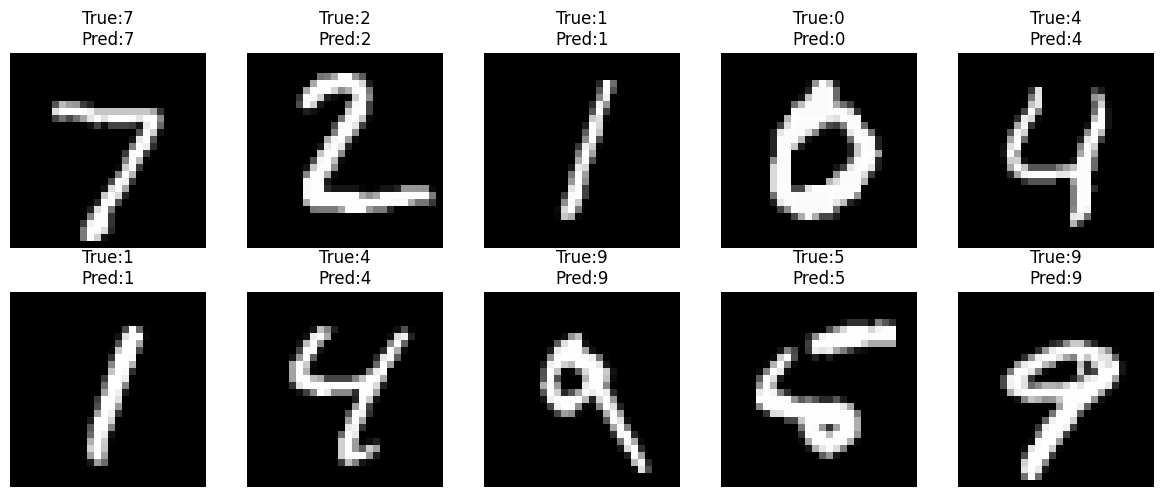

In [17]:
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"True:{y_test[i]}\nPred:{y_pred[i]}")
    plt.axis('off')
    
plt.tight_layout()
plt.savefig("results/sample_predictions.png")
plt.show()

Total Misclassified Images: 52


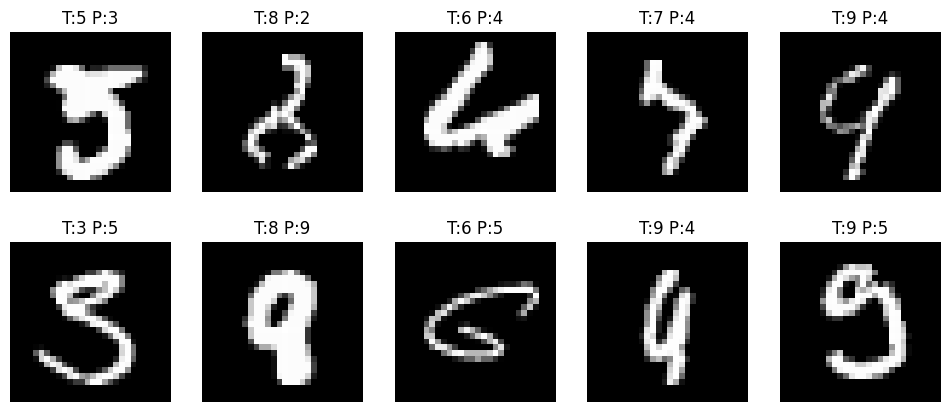

In [18]:
misclassified = np.where(y_pred != y_test)[0]
print("Total Misclassified Images:", len(misclassified))
plt.figure(figsize=(12,5))

for i, index in enumerate(misclassified[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[index].reshape(28,28), cmap='gray')
    plt.title(f"T:{y_test[index]} P:{y_pred[index]}")
    plt.axis("off")
    
plt.savefig("results/misclassified.png")
plt.show()